In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle

# Load the data
df = pd.read_csv('concat.csv')

print("Original class distribution:")
original_dist = df['Driving Regime'].value_counts().sort_index()
print(original_dist)

min_size = original_dist.min()
print(f"Smallest class size: {min_size}")

def analyze_temporal_patterns(data, class_label):
    """Analyze temporal patterns and segment characteristics for a class"""
    class_data = data[data['Driving Regime'] == class_label].copy()
    
    # Find continuous segments
    class_data['segment_id'] = (class_data.index != class_data.index.to_series().shift() + 1).cumsum()
    
    segments_info = []
    for seg_id, segment in class_data.groupby('segment_id'):
        seg_info = {
            'segment_id': seg_id,
            'length': len(segment),
            'start_idx': segment.index[0],
            'end_idx': segment.index[-1],
            'mean_speed': segment['Mean Speed'].mean(),
            'mean_accel': segment['Mean Acceleration'].mean(),
            'speed_std': segment['Mean Speed'].std(),
            'data': segment
        }
        segments_info.append(seg_info)
    
    return sorted(segments_info, key=lambda x: x['length'], reverse=True)

def select_optimal_segments(segments_info, target_size, diversity_factor=0.3):
    """Select segments that maximize continuity AND represent different driving conditions"""
    selected_segments = []
    remaining_size = target_size
    
    # Phase 1: Select the longest continuous segments
    long_segments = [seg for seg in segments_info if seg['length'] >= target_size * 0.5]
    
    if long_segments:
        # Try to get everything from one very long segment
        for segment in long_segments:
            if segment['length'] >= target_size:
                return [segment['data'].head(target_size)]
        
        # Use the longest segment as base
        base_segment = long_segments[0]
        base_size = min(base_segment['length'], int(target_size * 0.7))
        selected_segments.append(base_segment['data'].head(base_size))
        remaining_size -= base_size
    
    # Phase 2: Add complementary segments for diversity
    if remaining_size > 0:
        # Sort remaining segments by diversity (different speed/acceleration patterns)
        other_segments = segments_info.copy()
        if long_segments:
            other_segments = [seg for seg in other_segments if seg['segment_id'] != long_segments[0]['segment_id']]
        
        # Score segments by how different they are from already selected ones
        if selected_segments:
            current_mean_speed = pd.concat(selected_segments)['Mean Speed'].mean()
            current_mean_accel = pd.concat(selected_segments)['Mean Acceleration'].mean()
            
            for seg in other_segments:
                speed_diff = abs(seg['mean_speed'] - current_mean_speed)
                accel_diff = abs(seg['mean_accel'] - current_mean_accel)
                seg['diversity_score'] = speed_diff + accel_diff
            other_segments.sort(key=lambda x: x.get('diversity_score', 0), reverse=True)
        
        # Select diverse segments to fill remaining quota
        for segment in other_segments:
            if remaining_size <= 0:
                break
            take_size = min(segment['length'], remaining_size)
            selected_segments.append(segment['data'].head(take_size))
            remaining_size -= take_size
    
    return selected_segments

def create_highly_continuous_balanced_dataset(df, min_size_per_class):
    """Create a balanced dataset with maximum continuity and pattern diversity"""
    balanced_segments = {}
    continuity_metrics = {}
    
    for regime in sorted(df['Driving Regime'].unique()):
        print(f"\nProcessing Class {regime}:")
        
        # Analyze temporal patterns
        segments_info = analyze_temporal_patterns(df, regime)
        print(f"  Found {len(segments_info)} continuous segments")
        print(f"  Longest segment: {segments_info[0]['length']} samples")
        
        # Select optimal segments
        selected_data_list = select_optimal_segments(segments_info, min_size_per_class)
        selected_data = pd.concat(selected_data_list) if len(selected_data_list) > 1 else selected_data_list[0]
        
        # Ensure exact size
        if len(selected_data) > min_size_per_class:
            selected_data = selected_data.head(min_size_per_class)
        
        # Calculate continuity metrics
        indices = selected_data.index
        gaps = indices.to_series().diff()
        max_gap = gaps.max()
        num_blocks = (gaps > 1).sum() + 1
        avg_block_length = len(selected_data) / num_blocks
        
        balanced_segments[regime] = selected_data
        continuity_metrics[regime] = {
            'samples': len(selected_data),
            'max_gap': max_gap,
            'num_blocks': num_blocks,
            'avg_block_length': avg_block_length,
            'continuity_score': avg_block_length
        }
        
        print(f"  Selected {len(selected_data)} samples")
        print(f"  Continuity: {num_blocks} blocks, avg length: {avg_block_length:.1f}")
    
    return balanced_segments, continuity_metrics

# Create the highly continuous balanced dataset
balanced_segments, metrics = create_highly_continuous_balanced_dataset(df, min_size)

# Combine all classes
balanced_dfs = list(balanced_segments.values())
balanced_df = pd.concat(balanced_dfs)

# Sort by original index to maintain temporal relationships
balanced_df = balanced_df.sort_index().reset_index(drop=True)

print("\n" + "="*50)
print("FINAL BALANCED DATASET ANALYSIS")
print("="*50)

print("\nClass distribution:")
print(balanced_df['Driving Regime'].value_counts().sort_index())

print("\nContinuity Metrics by Class:")
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

print(f"\nOverall Statistics:")
print(f"Total samples: {len(balanced_df)}")
print(f"Number of classes: {len(balanced_df['Driving Regime'].unique())}")
print(f"Average continuity score: {metrics_df['continuity_score'].mean():.2f}")

# Calculate data diversity
diversity_scores = []
for regime in balanced_df['Driving Regime'].unique():
    regime_data = balanced_df[balanced_df['Driving Regime'] == regime]
    speed_std = regime_data['Mean Speed'].std()
    accel_std = regime_data['Mean Acceleration'].std()
    diversity_scores.append(speed_std + accel_std)

print(f"Average diversity score: {np.mean(diversity_scores):.3f}")

# Save the optimized dataset
balanced_df.to_csv('optimized_continuous_balanced_concat.csv', index=False)
print(f"\nOptimized continuous balanced dataset saved!")

# FIXED Temporal Split Function
def temporal_train_val_split(data, val_ratio=0.2):
    """Split data while maintaining temporal continuity within splits"""
    # Group by original continuous segments
    data = data.copy()
    data['temp_segment'] = (data.index != data.index.to_series().shift() + 1).cumsum()
    
    segments = []
    for seg_id, segment in data.groupby('temp_segment'):
        segments.append(segment)
    
    # Shuffle segments (not individual rows)
    segments = shuffle(segments, random_state=42)
    
    # Calculate split sizes
    val_size = int(len(data) * val_ratio)
    
    train_segments, val_segments = [], []
    current_val_size = 0
    
    for segment in segments:
        if current_val_size < val_size:
            val_segments.append(segment)
            current_val_size += len(segment)
        else:
            train_segments.append(segment)
    
    # Handle empty lists
    if not train_segments:
        # If train_segments is empty, move last segment from val to train
        if val_segments:
            last_segment = val_segments.pop()
            train_segments.append(last_segment)
    
    if not val_segments:
        # If val_segments is empty, move first segment from train to val
        if train_segments:
            first_segment = train_segments.pop(0)
            val_segments.append(first_segment)
    
    # Concatenate with safety checks
    train_df = pd.concat(train_segments).drop('temp_segment', axis=1) if train_segments else pd.DataFrame()
    val_df = pd.concat(val_segments).drop('temp_segment', axis=1) if val_segments else pd.DataFrame()
    
    # Final safety check - ensure we have both splits
    if len(train_df) == 0 or len(val_df) == 0:
        # Fallback: simple split
        split_idx = int(len(data) * (1 - val_ratio))
        train_df = data.iloc[:split_idx].drop('temp_segment', axis=1)
        val_df = data.iloc[split_idx:].drop('temp_segment', axis=1)
    
    return train_df, val_df

# Create temporal splits
train_df, val_df = temporal_train_val_split(balanced_df, val_ratio=0.2)

print(f"\nTemporal Split:")
print(f"Training set: {len(train_df)} samples ({len(train_df)/len(balanced_df)*100:.1f}%)")
print(f"Validation set: {len(val_df)} samples ({len(val_df)/len(balanced_df)*100:.1f}%)")

# Check class distribution in splits
print(f"\nTraining set class distribution:")
print(train_df['Driving Regime'].value_counts().sort_index())
print(f"\nValidation set class distribution:")
print(val_df['Driving Regime'].value_counts().sort_index())

# Save the datasets
train_df.to_csv('temporal_train_set.csv', index=False)
val_df.to_csv('temporal_val_set.csv', index=False)
print("\nTemporal train/validation sets saved!")

# Additional: Create a more balanced validation set
def create_balanced_val_set(data, val_ratio=0.2):
    """Create validation set with balanced classes"""
    val_dfs = []
    
    for regime in data['Driving Regime'].unique():
        regime_data = data[data['Driving Regime'] == regime]
        val_size = max(1, int(len(regime_data) * val_ratio))
        
        # Take continuous segments from the end for validation
        regime_data_sorted = regime_data.sort_index()
        val_data = regime_data_sorted.tail(val_size)
        val_dfs.append(val_data)
    
    val_df_balanced = pd.concat(val_dfs).sort_index()
    train_df_balanced = data.drop(val_df_balanced.index)
    
    return train_df_balanced, val_df_balanced

# Create balanced splits
train_balanced, val_balanced = create_balanced_val_set(balanced_df, val_ratio=0.2)

print(f"\nBalanced Split:")
print(f"Training set: {len(train_balanced)} samples")
print(f"Validation set: {len(val_balanced)} samples")
print(f"Validation class distribution:")
print(val_balanced['Driving Regime'].value_counts().sort_index())

train_balanced.to_csv('balanced_train_set.csv', index=False)
val_balanced.to_csv('balanced_val_set.csv', index=False)
print("Balanced train/validation sets saved!")

Original class distribution:
Driving Regime
0    375476
1    279193
2    157436
3    153787
4     80094
5      9498
Name: count, dtype: int64
Smallest class size: 9498

Processing Class 0:
  Found 30165 continuous segments
  Longest segment: 158 samples
  Selected 9498 samples
  Continuity: 55 blocks, avg length: 172.7

Processing Class 1:
  Found 10924 continuous segments
  Longest segment: 195 samples
  Selected 9498 samples
  Continuity: 47 blocks, avg length: 202.1

Processing Class 2:
  Found 16599 continuous segments
  Longest segment: 106 samples
  Selected 9498 samples
  Continuity: 177 blocks, avg length: 53.7

Processing Class 3:
  Found 16359 continuous segments
  Longest segment: 76 samples
  Selected 9498 samples
  Continuity: 231 blocks, avg length: 41.1

Processing Class 4:
  Found 8404 continuous segments
  Longest segment: 61 samples
  Selected 9498 samples
  Continuity: 276 blocks, avg length: 34.4

Processing Class 5:
  Found 226 continuous segments
  Longest segment

: 

In [2]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('concat.csv')

print("Original class distribution:")
original_dist = df['Driving Regime'].value_counts().sort_index()
print(original_dist)

min_size = original_dist.min()
print(f"Smallest class size: {min_size}")

def create_robust_balanced_dataset(df, min_size_per_class):
    """Create balanced dataset optimized for generalization"""
    balanced_data = {}
    
    for regime in sorted(df['Driving Regime'].unique()):
        print(f"Processing Class {regime}:")
        regime_data = df[df['Driving Regime'] == regime].copy()
        
        # Find continuous segments
        regime_data['segment_id'] = (regime_data.index != regime_data.index.to_series().shift() + 1).cumsum()
        
        segments = []
        for seg_id, segment in regime_data.groupby('segment_id'):
            segments.append({
                'id': seg_id,
                'data': segment,
                'length': len(segment),
                'start_idx': segment.index[0],
                'mean_speed': segment['Mean Speed'].mean(),
                'mean_accel': segment['Mean Acceleration'].mean()
            })
        
        # Sort by length (longest first)
        segments.sort(key=lambda x: x['length'], reverse=True)
        
        # Strategy: Use longest segments but ensure temporal diversity
        selected_segments = []
        remaining = min_size_per_class
        
        # Take from longest segments first
        for seg in segments:
            if remaining <= 0:
                break
            take_size = min(seg['length'], remaining)
            selected_data = seg['data'].head(take_size)
            selected_segments.append(selected_data)
            remaining -= take_size
        
        # Combine selected data
        if selected_segments:
            regime_balanced = pd.concat(selected_segments)
            if len(regime_balanced) > min_size_per_class:
                regime_balanced = regime_balanced.head(min_size_per_class)
        else:
            # Fallback: random sampling
            regime_balanced = regime_data.sample(min_size_per_class, random_state=42)
        
        balanced_data[regime] = regime_balanced
        print(f"  Selected {len(regime_balanced)} samples from {len(selected_segments)} segments")
    
    return balanced_data

def create_generalizable_splits(balanced_df, n_splits=5):
    """Create splits that prevent temporal leakage and ensure class balance"""
    balanced_df = balanced_df.copy().reset_index(drop=True)
    
    # Method 1: Simple stratified K-fold (most reliable)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    stratified_splits = []
    X = balanced_df.drop('Driving Regime', axis=1)
    y = balanced_df['Driving Regime']
    
    for train_idx, test_idx in skf.split(X, y):
        stratified_splits.append((train_idx.tolist(), test_idx.tolist()))
    
    return stratified_splits

def create_temporal_splits(balanced_df, n_splits=5):
    """Create splits based on temporal segments to prevent leakage"""
    balanced_df = balanced_df.copy()
    
    # Reconstruct temporal segments from original indices
    balanced_df['original_idx'] = balanced_df.index
    balanced_df = balanced_df.sort_values('original_idx').reset_index(drop=True)
    
    # Create artificial temporal segments
    segment_size = max(10, len(balanced_df) // 20)  # Create 20 segments
    balanced_df['temporal_segment'] = balanced_df.index // segment_size
    
    segments = []
    for seg_id, segment in balanced_df.groupby('temporal_segment'):
        segments.append(segment)
    
    # Shuffle segments
    segments = shuffle(segments, random_state=42)
    
    # Distribute segments across folds
    folds = [[] for _ in range(n_splits)]
    for i, segment in enumerate(segments):
        fold_idx = i % n_splits
        folds[fold_idx].append(segment)
    
    # Create train/test indices
    temporal_splits = []
    for fold in range(n_splits):
        test_segments = folds[fold]
        train_segments = []
        
        for i, seg_list in enumerate(folds):
            if i != fold:
                train_segments.extend(seg_list)
        
        test_df = pd.concat(test_segments)
        train_df = pd.concat(train_segments)
        
        temporal_splits.append((train_df.index.tolist(), test_df.index.tolist()))
    
    return temporal_splits

# Create the balanced dataset
print("Creating robust balanced dataset...")
balanced_segments = create_robust_balanced_dataset(df, min_size)

# Combine all classes
balanced_dfs = list(balanced_segments.values())
balanced_df = pd.concat(balanced_dfs)

# Shuffle to break any remaining temporal patterns
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal balanced dataset: {len(balanced_df)} samples")
print("Class distribution:")
print(balanced_df['Driving Regime'].value_counts().sort_index())

# Create multiple validation strategies
print("\n" + "="*60)
print("CREATING GENERALIZABLE CROSS-VALIDATION SPLITS")
print("="*60)

# Strategy 1: Stratified K-Fold (Most reliable)
print("\n1. Stratified K-Fold Cross-Validation:")
stratified_splits = create_generalizable_splits(balanced_df, n_splits=5)

for i, (train_idx, test_idx) in enumerate(stratified_splits):
    train_data = balanced_df.iloc[train_idx]
    test_data = balanced_df.iloc[test_idx]
    
    print(f"Fold {i+1}:")
    print(f"  Train: {len(train_idx)} samples, Classes: {dict(sorted(train_data['Driving Regime'].value_counts().items()))}")
    print(f"  Test:  {len(test_idx)} samples, Classes: {dict(sorted(test_data['Driving Regime'].value_counts().items()))}")

# Strategy 2: Temporal splits
print("\n2. Temporal Cross-Validation:")
temporal_splits = create_temporal_splits(balanced_df, n_splits=5)

for i, (train_idx, test_idx) in enumerate(temporal_splits):
    train_data = balanced_df.iloc[train_idx]
    test_data = balanced_df.iloc[test_idx]
    
    print(f"Fold {i+1}:")
    print(f"  Train: {len(train_idx)} samples, Classes: {dict(sorted(train_data['Driving Regime'].value_counts().items()))}")
    print(f"  Test:  {len(test_idx)} samples, Classes: {dict(sorted(test_data['Driving Regime'].value_counts().items()))}")

# Save the main balanced dataset
balanced_df.to_csv('generalizable_balanced_dataset.csv', index=False)
print(f"\nGeneralizable balanced dataset saved!")

# Create and save individual folds
for i, (train_idx, test_idx) in enumerate(stratified_splits):
    train_fold = balanced_df.iloc[train_idx]
    test_fold = balanced_df.iloc[test_idx]
    
    train_fold.to_csv(f'cv_fold_{i+1}_train.csv', index=False)
    test_fold.to_csv(f'cv_fold_{i+1}_test.csv', index=False)

print("Cross-validation folds saved!")

# Create a final train/validation split for quick testing
def create_final_split(balanced_df, test_size=0.2):
    """Create a final train/test split with stratification"""
    from sklearn.model_selection import train_test_split
    
    X = balanced_df.drop('Driving Regime', axis=1)
    y = balanced_df['Driving Regime']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42, shuffle=True
    )
    
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)
    
    return train_df, test_df

print("\n3. Final Stratified Train/Test Split:")
train_final, test_final = create_final_split(balanced_df, test_size=0.2)

print(f"Final split:")
print(f"Train: {len(train_final)} samples")
print(f"Test:  {len(test_final)} samples")
print(f"Train classes: {dict(sorted(train_final['Driving Regime'].value_counts().items()))}")
print(f"Test classes:  {dict(sorted(test_final['Driving Regime'].value_counts().items()))}")

train_final.to_csv('final_train.csv', index=False)
test_final.to_csv('final_test.csv', index=False)
print("Final train/test splits saved!")

# Additional: Create feature analysis to help with model tuning
print("\n" + "="*60)
print("FEATURE ANALYSIS FOR BETTER MODEL PERFORMANCE")
print("="*60)

feature_stats = balanced_df.groupby('Driving Regime').agg({
    'Mean Speed': ['mean', 'std'],
    'Mean Acceleration': ['mean', 'std'],
    'Spacing': ['mean', 'std'],
    'Relative Speed': ['mean', 'std']
}).round(3)

print("Feature statistics by driving regime:")
print(feature_stats)

# Check for potential feature engineering opportunities
print("\nFeature correlations with target:")
correlations = []
for col in ['Mean Speed', 'Mean Acceleration', 'Spacing', 'Relative Speed']:
    corr = balanced_df[col].corr(balanced_df['Driving Regime'].astype('category').cat.codes)
    correlations.append((col, abs(corr)))

correlations.sort(key=lambda x: x[1], reverse=True)
for col, corr in correlations:
    print(f"  {col}: {corr:.3f}")

print("\n" + "="*60)
print("TRAINING RECOMMENDATIONS:")
print("1. Use 'final_train.csv' and 'final_test.csv' for quick experiments")
print("2. Use cross-validation folds for reliable accuracy estimation") 
print("3. Monitor: Training accuracy ~90%, Validation accuracy should be 85-88%")
print("4. If gap > 5%, try: regularization, dropout, or simpler model")
print("5. Consider feature engineering based on correlations above")
print("="*60)

Original class distribution:
Driving Regime
0    375476
1    279193
2    157436
3    153787
4     80094
5      9498
Name: count, dtype: int64
Smallest class size: 9498
Creating robust balanced dataset...
Processing Class 0:
  Selected 9498 samples from 88 segments
Processing Class 1:
  Selected 9498 samples from 72 segments
Processing Class 2:
  Selected 9498 samples from 208 segments
Processing Class 3:
  Selected 9498 samples from 256 segments
Processing Class 4:
  Selected 9498 samples from 306 segments
Processing Class 5:
  Selected 9498 samples from 226 segments

Final balanced dataset: 56988 samples
Class distribution:
Driving Regime
0    9498
1    9498
2    9498
3    9498
4    9498
5    9498
Name: count, dtype: int64

CREATING GENERALIZABLE CROSS-VALIDATION SPLITS

1. Stratified K-Fold Cross-Validation:
Fold 1:
  Train: 45590 samples, Classes: {0: 7599, 1: 7598, 2: 7599, 3: 7598, 4: 7598, 5: 7598}
  Test:  11398 samples, Classes: {0: 1899, 1: 1900, 2: 1899, 3: 1900, 4: 1900, 5: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("final_train.csv")

In [3]:
df["Driving Regime"].value_counts()

Driving Regime
0    7599
1    7599
4    7598
5    7598
3    7598
2    7598
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X=df.drop(columns=["Driving Regime","Unnamed: 0","segment_id"])
y=df["Driving Regime"]

In [6]:
X.head()

,LocalY,Mean Speed,Mean Acceleration,LocalY_leader,Mean Speed_leader,Spacing,Relative Speed
0,69.88320,0.00000,0.00000,80.98121,0.00000,11.09801,0.00000
1,231.89290,7.20848,1.74577,250.23180,7.37667,18.33890,0.16819
2,82.18504,3.47153,1.00671,103.65070,6.31133,21.46566,2.83980
3,122.87054,5.28473,-1.04126,144.28223,1.99608,21.41169,-3.28865
4,63.36240,1.74596,-0.00343,76.83127,1.63691,13.46887,-0.10905


In [7]:
y.head()

0    5
1    4
2    4
3    1
4    0
Name: Driving Regime, dtype: int64

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Input
model=Sequential()
model.add(Input(shape=(7,)))
model.add(Dense(1024,activation="relu"))
model.add(Dense(512,activation="relu"))
model.add(Dense(264,activation="relu"))
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(6,activation="softmax"))

In [32]:
model.compile(optimizer="Adam",metrics=["accuracy"],loss="sparse_categorical_crossentropy")
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),verbose=1,epochs=250,batch_size=256)

Epoch 1/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2910 - loss: 1.8779 - val_accuracy: 0.4050 - val_loss: 1.4627
Epoch 2/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5347 - loss: 1.1426 - val_accuracy: 0.5897 - val_loss: 0.9345
Epoch 3/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6329 - loss: 0.8077 - val_accuracy: 0.6002 - val_loss: 0.9447
Epoch 4/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6655 - loss: 0.7149 - val_accuracy: 0.6799 - val_loss: 0.7348
Epoch 5/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6713 - loss: 0.6935 - val_accuracy: 0.6942 - val_loss: 0.6449
Epoch 6/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6856 - loss: 0.6572 - val_accuracy: 0.6767 - val_loss: 0.6849
Epoch 7/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6935 - loss: 0.6298 - val_accuracy: 0.6992 - val_loss: 0.6300
Epoch 8/250
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6975 - loss: 0.6323 - val_ac

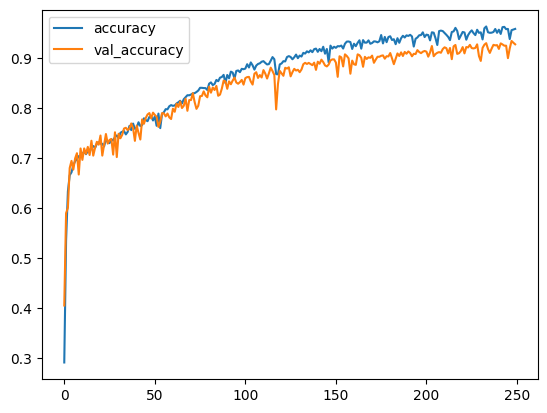

In [35]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.legend()

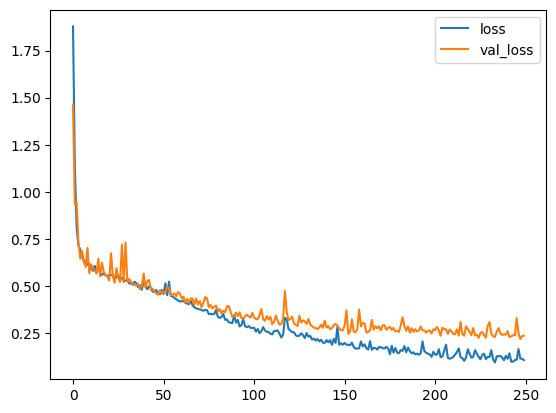

In [34]:
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()